## Import Necessary Libraries

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm
import scipy.stats as stats

## Load the Dataset

In [20]:
data  = pd.read_csv("C:/Users/Michael Faraday/Desktop/Machine Learning/File Dataset/marketing_data.csv")


## Explore data

In [112]:
data.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


## Summary Statistics

In [13]:
data.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [14]:
data.tail()

,TV,Radio,Social_Media,Sales
4567,26.0,4.472360,0.717090,94.685866
4568,71.0,20.610685,6.545573,249.101915
4569,44.0,19.800072,5.096192,163.631457
4570,71.0,17.534640,1.940873,253.610411
4571,42.0,15.966688,5.046548,148.202414


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [18]:
data.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [32]:
print("=" * 80)
print("--------------------------Data Types--------------------")
print("=" * 80)
print(type("TV"))
print(type("Radio"))
print(type("Social_Media"))
print(type("Sales"))

--------------------------Data Types--------------------
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [33]:
data.shape

(4572, 4)

## Handle Missing Values

In [35]:
missing_percentage = data.isnull().sum() / len(data) * 100
missing_percentage

TV              0.218723
Radio           0.087489
Social_Media    0.131234
Sales           0.131234
dtype: float64

In [37]:
data["TV"].fillna(data["TV"].mean(), inplace = True)
data["Radio"].fillna(data["Radio"].mean(), inplace = True)
data["Social_Media"].fillna(data["Social_Media"].mean(), inplace = True)
data["Sales"].fillna(data["Sales"].mean(), inplace = True)

C:\Users\Michael Faraday\AppData\Local\Temp\ipykernel_13456\3662519481.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["TV"].fillna(data["TV"].mean(), inplace = True)
C:\Users\Michael Faraday\AppData\Local\Temp\ipykernel_13456\3662519481.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4572 non-null   float64
 1   Radio         4572 non-null   float64
 2   Social_Media  4572 non-null   float64
 3   Sales         4572 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [41]:
data.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

## Exploratory Data Analysis (EDA) with Visualizations

#### Plot graph of all entities


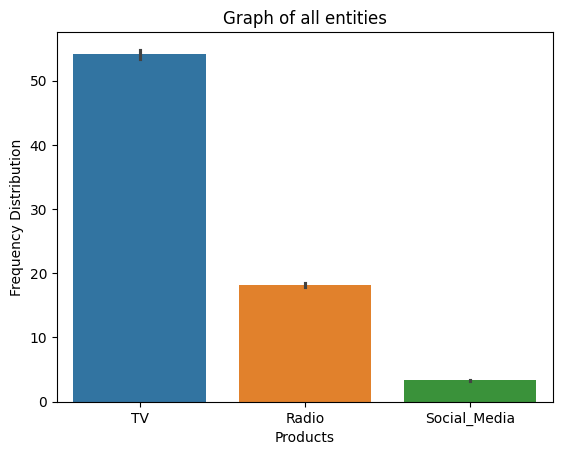

In [46]:

data_display = data.drop(columns = "Sales")

sns.barplot(data = data_display)
plt.title("Graph of all entities")
plt.xlabel("Products")
plt.ylabel("Frequency Distribution")
plt.show()

## Graph of TV Sales against Sales

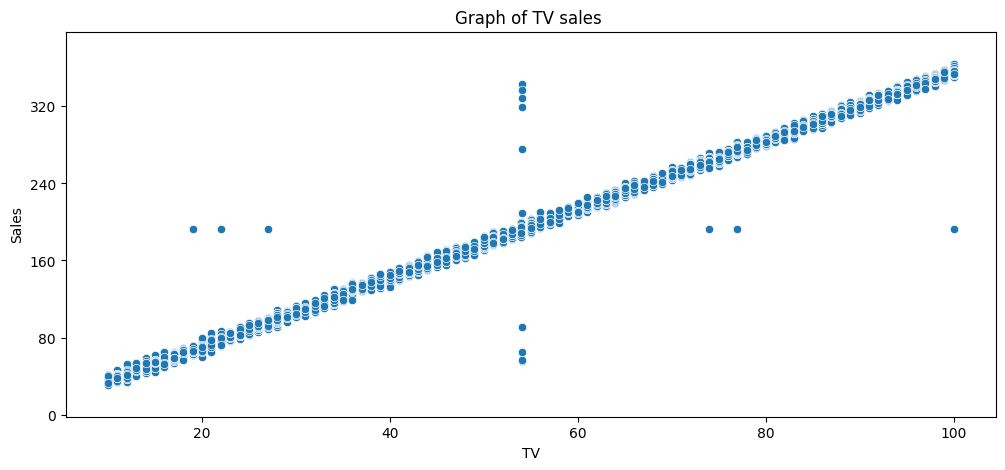

In [56]:
fig, ax = plt.subplots(figsize = (12, 5))

## scatteerplot for continous x-axis
sns.scatterplot(data = data, x = "TV", y = "Sales")

## Add spacing on y-axis
ax.margins(y = 0.1)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins = 6))
plt.title("Graph of TV sales ")
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()

#### The graph display a strong poitive correlation of TV sales against Sales but indicated few outliers in the data.

## Graph of Radio sales against Sales 

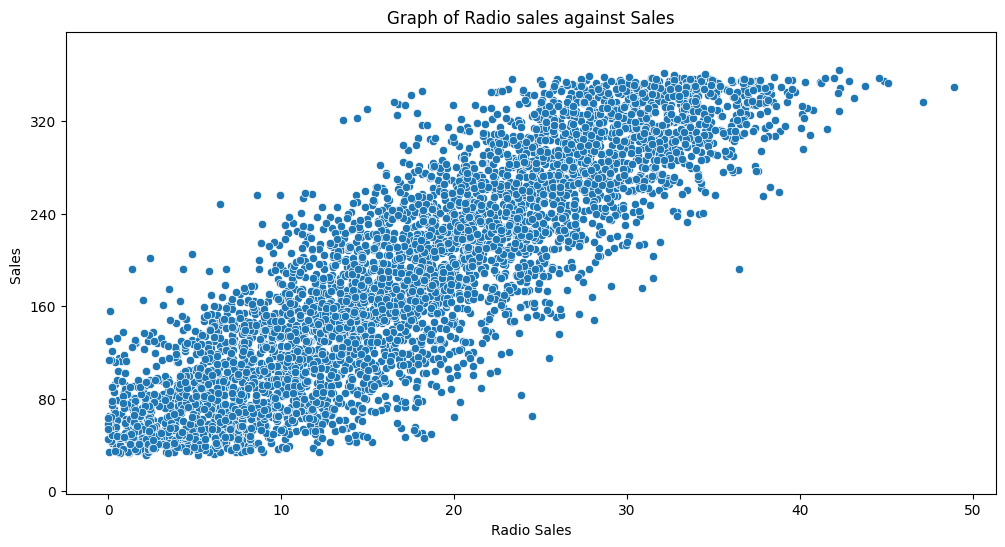

In [58]:
fig, ax = plt.subplots(figsize  = (12, 6))

##scatterplot for continous x-axis
sns.scatterplot(data = data, x = "Radio", y = "Sales")

## Add spacing on y-axis
ax.margins(y = 0.1)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins = 6))
plt.title("Graph of Radio sales against Sales")
plt.xlabel("Radio Sales")
plt.ylabel("Sales ")
plt.show()

The correlation graph of Radio shows a slightly weak correlation with sales according to the analysis.

## Graph of Social media against Sales

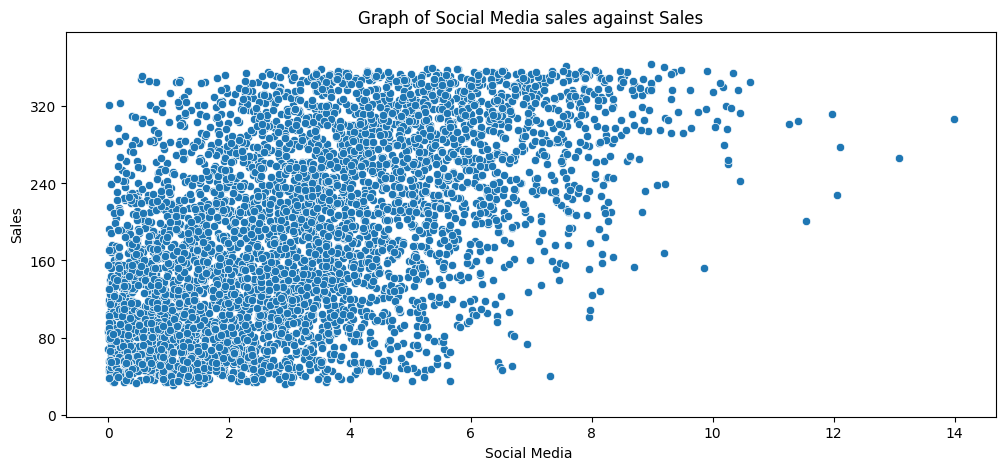

In [61]:
fig, ax = plt.subplots(figsize = (12, 5))

## scatterplot for continous x-axis
sns.scatterplot(data = data, x = "Social_Media", y = "Sales")

## Add spacing on y-axis
ax.margins(y = 0.1)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins = 6))
plt.title("Graph of Social Media sales against Sales")
plt.xlabel("Social Media ")
plt.ylabel("Sales")
plt.show()

The correlation of social media to sales shows a very weak corrrelation.

## Complete Summary of all data correlations

------------------------------------------Correlations among all products---------------------------------------
Sales           1.000000
TV              0.996652
Radio           0.867369
Social_Media    0.528121
Name: Sales, dtype: float64


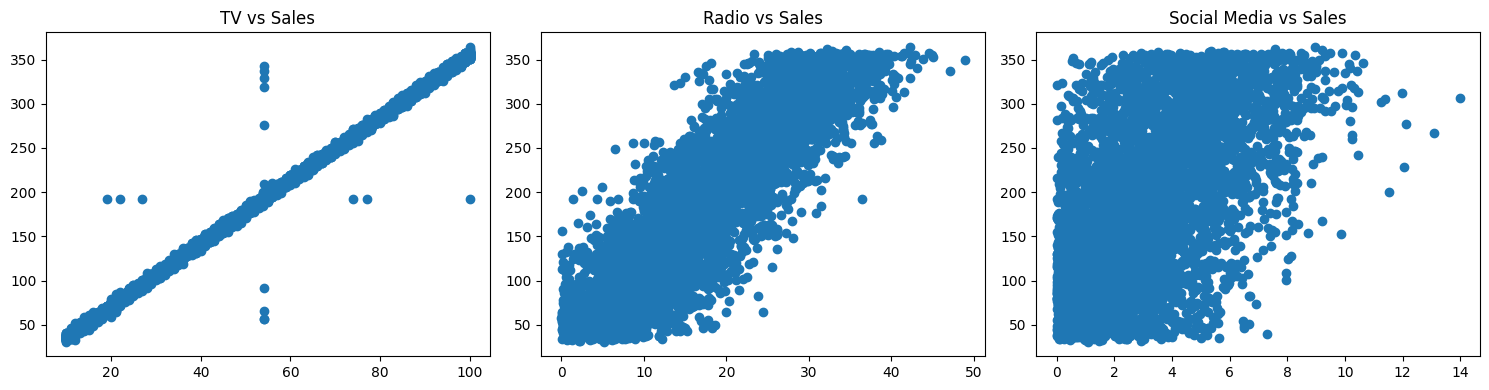

In [74]:
## Correlation Matrix
correlations = data.corr()["Sales"].sort_values(ascending = False)
print("=" * 120)
print("------------------------------------------Correlations among all products---------------------------------------")
print("=" * 120)
print(correlations)

## Scatterplots
fig, axes = plt.subplots(1, 3, figsize = (15, 4))
axes[0].scatter(data["TV"], data["Sales"])
axes[0].set_title("TV vs Sales")

axes[1].scatter(data["Radio"], data["Sales"])
axes[1].set_title("Radio vs Sales")

axes[2].scatter(data["Social_Media"], data["Sales"])
axes[2].set_title("Social Media vs Sales")

plt.tight_layout()
plt.show()

After my analysis on the data, i came to discover that among all the entities, 
- radio
- tv
- social media
the most correlated with sales is the tv.
TV shows a very strong positive correlation with sales followed by radio and then lastly the social media which shows the weakest correlation with sales.
Though with the TV, there were some observed outliers in the graph which could be normal.\
    

## Model Building

Selecting the best predictor, from the output, picking the highest correlated entity
TV is the most correlated entity so we will be picking the TV for the model building 

In [77]:
best_predictor = "TV"

print(f"Selected Variable: {best_predictor}")

Selected Variable: TV


## Building and Fitting the OLS model

In [80]:
## Define x and y

x = data[best_predictor]
y = data["Sales"]

## Add constants (constant terms)
x_with_const = sm.add_constant(x)

# Fit Model
model = sm.OLS(y, x_with_const).fit()

# Print model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 6.792e+05
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:11:37   Log-Likelihood:                -15765.
No. Observations:                4572   AIC:                         3.153e+04
Df Residuals:                    4570   BIC:                         3.155e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2849      0.259      1.100      0.2

## Validation and Diagnostics

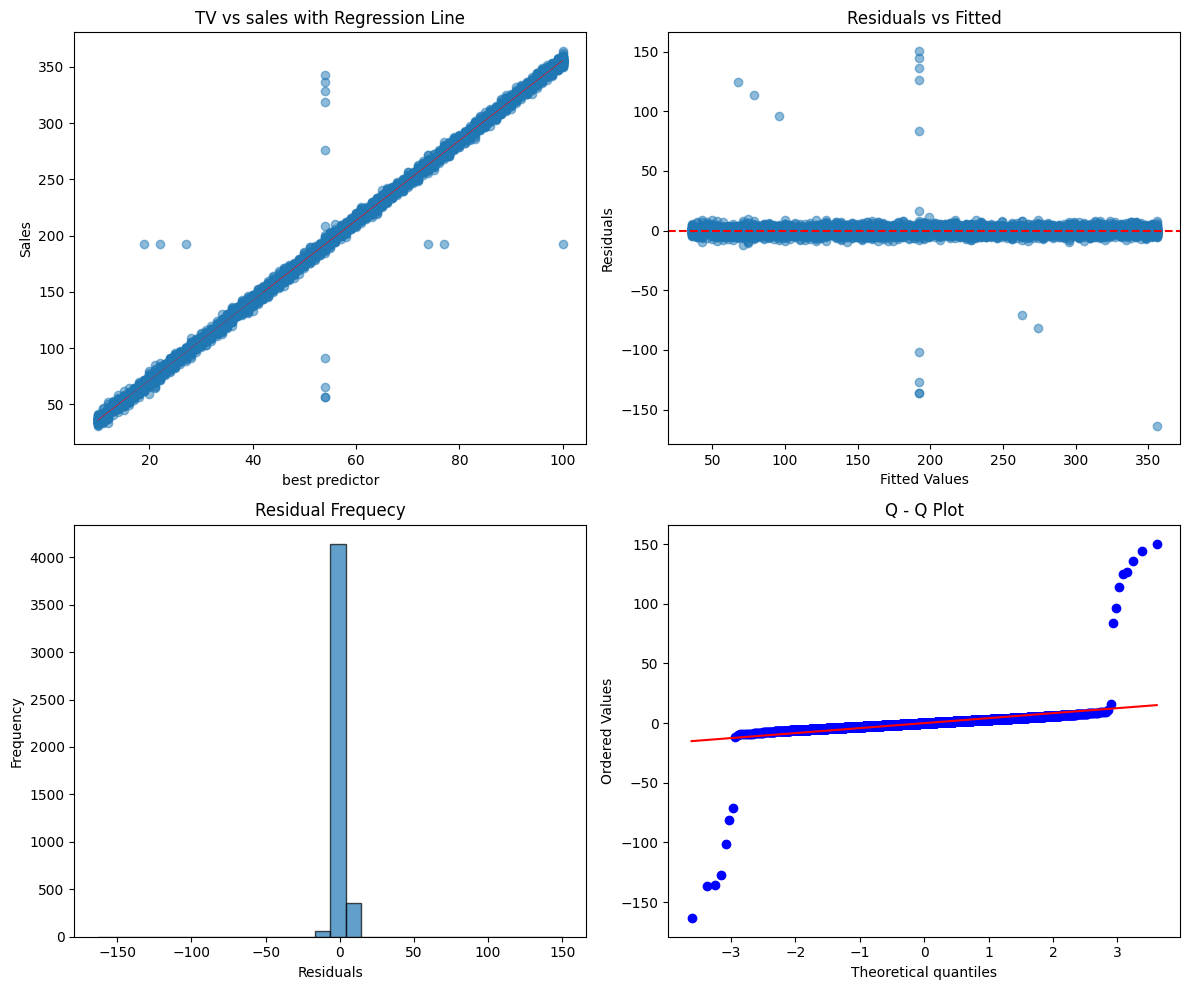

In [86]:
## Get predictions and residuals

predictions = model.predict(x_with_const)

residuals = y - predictions

# Create disgnostic plot
    
fig, axes = plt.subplots(2, 2, figsize = (12, 10))

# 1. Scatterplot with regression line
axes[0,0].scatter(x, y, alpha = 0.5)
axes[0,0].plot(x, predictions, color = "red", linewidth = 0.2)
axes[0,0].set_xlabel("best predictor")
axes[0,0].set_ylabel("Sales")
axes[0,0].set_title(f"{best_predictor} vs sales with Regression Line")

# 2. Residuals vs Fitted (Homoscedasticity)
axes[0,1].scatter(predictions, residuals, alpha = 0.5)
axes[0,1].axhline(y = 0, color = "red", linestyle = "--")
axes[0,1].set_xlabel("Fitted Values")
axes[0,1].set_ylabel("Residuals")
axes[0,1].set_title("Residuals vs Fitted")

# 3. Histogram of Residuals (Normality Check)
axes[1,0].hist(residuals, bins = 30, edgecolor = "black", alpha = 0.7)
axes[1,0].set_xlabel("Residuals")
axes[1,0].set_ylabel("Frequency")
axes[1,0].set_title("Residual Frequecy")

# 4. Q-Q plot (Normality Check)
stats.probplot(residuals, dist = "norm", plot = axes[1, 1])
axes[1,1].set_title("Q - Q Plot")

plt.tight_layout()
plt.show()

## Interpret Results

In [104]:
# Extract Key Metrics
r_squared = model.rsquared
coefficient = model.params[best_predictor]
p_value = model.pvalues[best_predictor]
intercepts = model.params["const"]

# Print out the outputs
print("="*120)
print("--------------------------------------------Results Interpretation-------------------------------------------")
print("="*120)

print(f"R-Squared: {r_squared:.4f} -> {r_squared *100:.1f}% of sales variations explained.")
print(f"Coefficient: {coefficient:.4f} -> Each unit of {best_predictor} increases sales by {coefficient:2f}")
print(f"P_values: {p_value:.4e} -> {'Significant' if p_value < 0.05 else 'Not Significant'}")

--------------------------------------------Results Interpretation-------------------------------------------
R-Squared: 0.9933 -> 99.3% of sales variations explained.
Coefficient: 3.5545 -> Each unit of TV increases sales by 3.554520
P_values: 0.0000e+00 -> Significant


## Business Recommendations

#### ROI-Based Recommendations

In [109]:
# Range Context
min_spend = data[best_predictor].min()
max_spend = data[best_predictor].max()
average_sales = data["Sales"].mean()

# Define the expected increament
increment = 10

# Calculate expected sales lift
expected_sales_increase = coefficient * increament

# Calculate ROI percentage (if assumed units  = 1000)
assumed_spend_amount = increament * 1000

roi_percentage = (expected_sales_increase / assumed_spend_amount) * 100

# print Recommendations
print("\n" + "=" * 110)
print(" " * 40  + "Business Recommendation report")
print("=" * 110)
print(f"\nn📊 Analysis Summary")
print(f"     • Data Analyzed: {len(data)} marketing campaign")
print(f"     • Best Performing Channel: {best_predictor}")
print(f"     • Sales Range in Data: {data['Sales'].min():.0f} - {data['Sales'].max():.0f}")
print(f"     • Average sales per Campaign: {average_sales:.0f} ")

print(f"\n📈 STATISTICAL RESULTS")
print(f"    • R-Squared: {r_squared:.3f} ({r_squared * 100:.1f}% of sales variations explained.)")
print(f"    • Coefficient: {coefficient:.4f}")
print(f"    • P-Value: {p_value:.6f}")
print(f"    • Statistical Significance: {'✅ YES (p < 0.05)' if p_value < 0.05 else '❌ NO (p > 0.05)'}")
print(f"\n💰 ROI INSIGHT (Based on {best_predictor} spend range: {min_spend} to {max_spend} units)")
print(f"   ┌{'─'*60}┐")
print(f"   │ For every {increment}-unit INCREASE in {best_predictor} spend:          │")
print(f"   │                                                                          │")
print(f"   │ → Expected Sales INCREASE = {expected_sales_increase:.2f} units                     │")
print(f"   └{'─'*60}┘")

print(f"\n💵 PRACTICAL BUSINESS INTERPRETATION")
print(f"   (Assuming 1 marketing spend unit = $1,000)")
print(f"   ┌{'─'*60}┐")
print(f"   │ Additional investment: ${increment * 1000:,} in {best_predictor}                  │")
print(f"   │ Expected sales return: {expected_sales_increase:.0f} sales units                      │")
print(f"   │ Estimated ROI: {roi_percentage:.1f}% return on ad spend                         │")
print(f"   └{'─'*60}┘")

print(f"\n✅ FINAL RECOMMENDATION")
print(f"   {'='*56}")
print(f"   🎯 ACTION: Reallocate marketing budget to prioritize {best_predictor}")
print(f"   ")
print(f"   • This channel shows the STRONGEST statistical relationship with Sales")
print(f"   • The relationship is LINEAR and PREDICTABLE (R² = {r_squared:.1%})")
print(f"   • The effect is STATISTICALLY SIGNIFICANT (p = {p_value:.6f})")
print(f"   ")
print(f"   💡 Next Steps:")
print(f"      1. Increase {best_predictor} budget by {increment} units (${increment*1000:,})")
print(f"      2. Monitor sales lift over next {len(data)} campaigns")
print(f"      3. Validate model predictions against actual results")

print("\n" + "="*70)
print(" " * 20 + "END OF RECOMMENDATION")
print("="*70)



                                        Business Recommendation report

n📊 Analysis Summary
     • Data Analyzed: 4572 marketing campaign
     • Best Performing Channel: TV
     • Sales Range in Data: 31 - 364
     • Average sales per Campaign: 192 

📈 STATISTICAL RESULTS
    • R-Squared: 0.993 (99.3% of sales variations explained.)
    • Coefficient: 3.5545
    • P-Value: 0.000000
    • Statistical Significance: ✅ YES (p < 0.05)

💰 ROI INSIGHT (Based on TV spend range: 10.0 to 100.0 units)
   ┌────────────────────────────────────────────────────────────┐
   │ For every 10-unit INCREASE in TV spend:          │
   │                                                                          │
   │ → Expected Sales INCREASE = 35.55 units                     │
   └────────────────────────────────────────────────────────────┘

💵 PRACTICAL BUSINESS INTERPRETATION
   (Assuming 1 marketing spend unit = $1,000)
   ┌────────────────────────────────────────────────────────────┐
   │ Additional inv